In [106]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [1]:
! pip install --upgrade scikit-learn scikeras

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2


**1. Data Exploration and Preprocessing**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df= pd.read_csv("sonardataset.csv")

In [4]:
df.shape

(208, 61)

In [5]:
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [7]:
# Number of samples and features
print("Number of Samples :", df.shape[0])
print("Number of Features :", df.shape[1]-1)

Number of Samples : 208
Number of Features : 60


In [8]:
df.dtypes

,0
x_1,float64
x_2,float64
x_3,float64
x_4,float64
x_5,float64
...,...
x_57,float64
x_58,float64
x_59,float64
x_60,float64


In [9]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
x_1     0
x_2     0
x_3     0
x_4     0
x_5     0
       ..
x_57    0
x_58    0
x_59    0
x_60    0
Y       0
Length: 61, dtype: int64


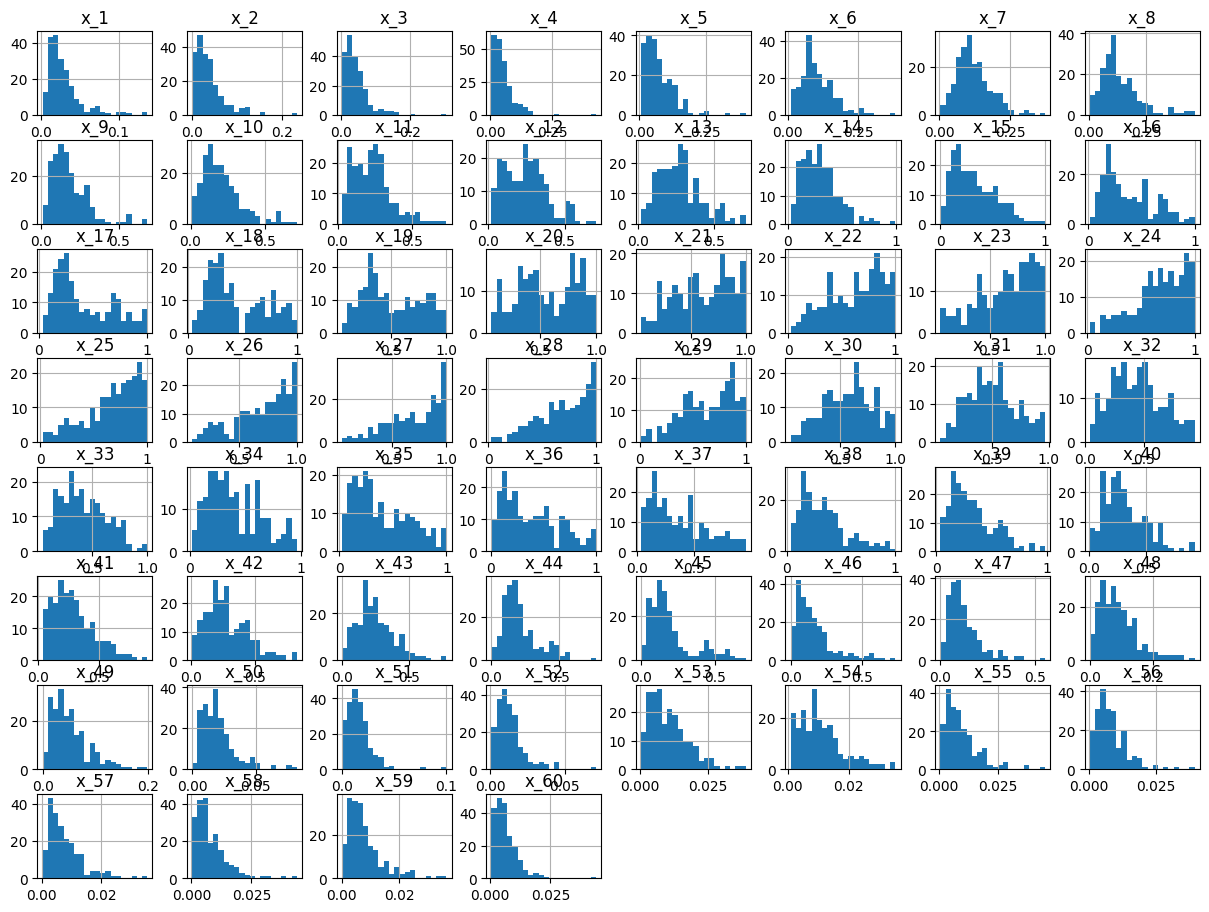

In [10]:
#histogram
df.hist(bins=20,figsize=(15,11))
plt.show()

In [11]:
# Separate features and target
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [12]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [13]:
# Class distribution
print("Class Distribution:")
print(y.value_counts())

Class Distribution:
Y
M    111
R     97
Name: count, dtype: int64


In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
# Split Dataset into Train and Test Sets
x_train, x_test, y_train, y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=50)

**2. Model Implementation**

In [17]:
import keras
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [24]:
# ANN model
model = tensorflow.keras.models.Sequential()
# Input Layer and Hidden Layer
model.add(tensorflow.keras.layers.Dense(units=41,activation='relu',input_shape=[60]))
# Output Layer
model.add(tensorflow.keras.layers.Dense(units=1,activation='sigmoid'))
# Model Compilation
model.compile(optimizer=tensorflow.keras.optimizers.Adam(),loss='binary_crossentropy',metrics=['accuracy'])

In [25]:
# Model Training
model.fit(x_train,y_train,epochs=50,batch_size=16,validation_split=0.2)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5455 - loss: 0.7114 - val_accuracy: 0.7647 - val_loss: 0.6211
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6894 - loss: 0.6013 - val_accuracy: 0.7353 - val_loss: 0.5806
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7652 - loss: 0.5196 - val_accuracy: 0.7353 - val_loss: 0.5604
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8182 - loss: 0.4673 - val_accuracy: 0.7353 - val_loss: 0.5433
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8182 - loss: 0.4234 - val_accuracy: 0.7059 - val_loss: 0.5345
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8409 - loss: 0.3916 - val_accuracy: 0.7059 - val_loss: 0.5259
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8561 - loss: 0.3641 - val_accuracy: 0.7059 - val_loss: 0.5169
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8712 - loss: 0.3419 - val_accuracy: 0.7059 - val_loss: 0.5086


In [26]:
loss,accuracy=model.evaluate(x_test,y_test)
print("loss",loss)
print("accuracy",accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8333 - loss: 0.4565
loss 0.4565376937389374
accuracy 0.8333333134651184


In [27]:
# Predictions

y_pred = model.predict(x_test)

y_pred = (y_pred > 0.5).astype(int)

print(y_pred[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]]


**3. Hyperparameter Tuning**

In [28]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

In [29]:
# ANN model
def create_my_model1():
  model = tensorflow.keras.models.Sequential()
  # Input Layer and Hidden Layer
  model.add(tensorflow.keras.layers.Dense(units=41,activation='relu',input_shape=[60]))
  # Output Layer
  model.add(tensorflow.keras.layers.Dense(units=1,activation='sigmoid'))
  # Model Compilation
  model.compile(optimizer=tensorflow.keras.optimizers.Adam(),loss='binary_crossentropy',metrics=['accuracy'])
  return model

In [30]:
model1 = KerasClassifier(
    model=create_my_model1,
    verbose=0
)

In [31]:
batch_values=[16,32]
epoch_size=[50,60]

In [32]:
params=dict(batch_size=batch_values,epochs=epoch_size)
params

{'batch_size': [16, 32], 'epochs': [50, 60]}

In [33]:
grid_search=GridSearchCV(estimator=model1,param_grid=params,cv=2)

In [34]:
grid_search.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'batch_size': [16, 32], 'epochs': [50, 60]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold an

In [36]:
###summary results
grid_search.best_score_,grid_search.best_params_

(np.float64(0.8493975903614458), {'batch_size': 16, 'epochs': 50})

In [42]:
# Best Batch Size and Epochs
print("Best Batch Size and Epochs")
print(grid_search.best_params_)

best_batch_size = grid_search.best_params_['batch_size']

best_epochs = grid_search.best_params_['epochs']

Best Batch Size and Epochs
{'batch_size': 16, 'epochs': 50}


In [43]:
optimizer_type=['SGD','RMSprop','Adagrad','Adam']
param_grid=dict(optimizer=optimizer_type)
param_grid

{'optimizer': ['SGD', 'RMSprop', 'Adagrad', 'Adam']}

In [44]:
def create_my_model(optimizer='SGD'):
  model = tensorflow.keras.models.Sequential()
  # Input Layer and Hidden Layer
  model.add(tensorflow.keras.layers.Dense(units=41,activation='relu',input_shape=[60]))
  # Output Layer
  model.add(tensorflow.keras.layers.Dense(units=1,activation='sigmoid'))
  # Model Compilation
  model.compile(optimizer=optimizer,loss=tensorflow.keras.losses.categorical_crossentropy,metrics=['accuracy'])
  return model

In [45]:
model2=KerasClassifier(build_fn=create_my_model,epochs=best_epochs,batch_size=best_batch_size)

In [46]:
grid_search2=GridSearchCV(estimator=model2,param_grid=param_grid,cv=3)

In [47]:
grid_search2.fit(x_train,y_train)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4364 - loss: 0.0000e+00  
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4636 - loss: 0.0000e+00 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4545 - loss: 0.0000e+00 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4545 - loss: 0.0000e+00 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4636 - loss: 0.0000e+00 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4636 - loss: 0.0000e+00 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4636 - loss: 0.0000e+00
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4636 - loss: 0.0000e+00
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4636 - loss: 0.0000e+00 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4636 - loss: 0.0000e+00 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4636 - loss: 0.0000e+00
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'optimizer': ['SGD', 'RMSprop', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [48]:
grid_search2.best_score_,grid_search2.best_params_

(np.float64(0.5055194805194806), {'optimizer': 'SGD'})

In [49]:
# final ANN model
final_model = tensorflow.keras.models.Sequential()
# Input Layer and Hidden Layer
final_model.add(tensorflow.keras.layers.Dense(units=41,activation='relu',input_shape=[60]))
# Output Layer
final_model.add(tensorflow.keras.layers.Dense(units=1,activation='sigmoid'))
# Model Compilation
final_model.compile(optimizer=tensorflow.keras.optimizers.SGD(),loss='binary_crossentropy',metrics=['accuracy'])

In [51]:
####model training and validation
history=final_model.fit(x_train,y_train,epochs=best_epochs,batch_size=best_batch_size,validation_data=(x_test,y_test))

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9578 - loss: 0.2039 - val_accuracy: 0.8095 - val_loss: 0.4184
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9639 - loss: 0.2010 - val_accuracy: 0.8095 - val_loss: 0.4199
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9639 - loss: 0.1984 - val_accuracy: 0.8095 - val_loss: 0.4185
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9639 - loss: 0.1958 - val_accuracy: 0.8095 - val_loss: 0.4175
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9639 - loss: 0.1928 - val_accuracy: 0.8095 - val_loss: 0.4171
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9639 - loss: 0.1907 - val_accuracy: 0.8095 - val_loss: 0.4158
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9639 - loss: 0.1878 - val_accuracy: 0.8095 - val_loss: 0.4149
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9639 - loss: 0.1853 - val_accuracy: 0.8095 - val_l

In [52]:
loss,accuracy=final_model.evaluate(x_test,y_test)
print("loss",loss)
print("accuracy",accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8571 - loss: 0.3975
loss 0.39749282598495483
accuracy 0.8571428656578064


In [53]:
# Predictions
y_pred = final_model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


**4. Evaluation**

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [56]:
# Predictions from Default Model

y_pred_default = model.predict(x_test)
y_pred_default = (y_pred_default > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [57]:
# Predictions from Tuned Model

y_pred_tuned = final_model.predict(x_test)
y_pred_tuned = (y_pred_tuned > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [58]:
# Default Model Evaluation
print("===== Default ANN Model =====")

print("Accuracy :",
      accuracy_score(y_test, y_pred_default))

print("Precision :",
      precision_score(y_test, y_pred_default))

print("Recall :",
      recall_score(y_test, y_pred_default))

print("F1 Score :",
      f1_score(y_test, y_pred_default))

print("\nClassification Report\n")

print(classification_report(y_test, y_pred_default))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, y_pred_default))

===== Default ANN Model =====
Accuracy : 0.8333333333333334
Precision : 0.7222222222222222
Recall : 0.8666666666666667
F1 Score : 0.7878787878787878

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.81      0.86        27
           1       0.72      0.87      0.79        15

    accuracy                           0.83        42
   macro avg       0.82      0.84      0.83        42
weighted avg       0.85      0.83      0.84        42


Confusion Matrix

[[22  5]
 [ 2 13]]


In [59]:
# Tuned Model Evaluation
print("===== Tuned ANN Model =====")

print("Accuracy :",
      accuracy_score(y_test, y_pred_tuned))

print("Precision :",
      precision_score(y_test, y_pred_tuned))

print("Recall :",
      recall_score(y_test, y_pred_tuned))

print("F1 Score :",
      f1_score(y_test, y_pred_tuned))

print("\nClassification Report\n")

print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, y_pred_tuned))

===== Tuned ANN Model =====
Accuracy : 0.8571428571428571
Precision : 0.8
Recall : 0.8
F1 Score : 0.8

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        27
           1       0.80      0.80      0.80        15

    accuracy                           0.86        42
   macro avg       0.84      0.84      0.84        42
weighted avg       0.86      0.86      0.86        42


Confusion Matrix

[[24  3]
 [ 3 12]]


In [60]:
# The tuned ANN model performs better because the selected hyperparameters allow the neural network to learn more effectively from sonar signal patterns.

**Effects of Hyperparameter Tuning:**

Hyperparameter tuning improves ANN model performance by selecting the best training parameters like epochs, batch size, optimizer, and neurons.

**It helps to:**

Increase accuracy

Improve prediction performance

Reduce overfitting and underfitting

Make training faster and more stable